**VERSION v5**: Uses new signal and satellite catalog.

## 1. Initialization

Imports and necessary parameters.

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import sys
sys.path.insert(0, "./initialization/")
from imports import *
import parameters as pm
import time


## 2. Creating the new beams file

#### A. Getting the data

Currently the beam model information for each satellite takes almost 1 minute to load and has some weird information, besides relying on the unreliable satellite names instead of a general ID (such as NORAD).

In [4]:
# getting individual satellites that appear
start = time.perf_counter()
fname = "{}{}_individual_satellite_angular_position_{}_beam_{}_{}MHz.p".format(
    pm.path_data,pm.block,pm.beam_model,*pm.freq_range)
f2 = pickle.load(open(fname,"rb",), encoding="latin1")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


This took 96.76 seconds, or 1.61 minutes


#### C. Checking beam model maps

I'm now checking the beam model maps; since the meerKAT array performs a zig-zag approach in this observation, it is expected to observe this zig-zag in the satellite beam model map (as the satellite appears repeatedly closer and farther from the telescope pointing, over which the satellite intensity should be biggest). 

However, there are some satellite which don't show this zig-zag and instead have smooth curves - these are completely unphysical!! These are also always 10-100x less intense than the other satellite maps; are these just artifacts? Should check this!!

**List of weird satellites:** 
- *GPS:* GPS-BIIRM-2, GPS-BIIR-9.
- *GALILEO:* GSAT0209, GSAT0210, GSAT0203.
- *IRNSS:* IRNSS-1C.
- *SBAS:* GSAT-15, LUCH-5V, GSAT-10.
- *GLONASS:* COSMOS-2492, COSMOS-2464, COSMOS-2433, COSMOS-2477.
- *BEIDOU:* BEIDOU-I1-S, BEIDOU-IGSO-6, BEIDOU-IGSO-5, BEIDOU-I2-S, BEIDOU-IGSO-3, BEIDOU-G6, BEIDOU-G3, BEIDOU-3-M8.

Satellites COSMOS-2425 (29670) and COSMOS-2458 (36113) luckily don't appear in the beam maps, and so the question of what to do with them (given that they had no k number) is now moot!

In [5]:
# cutting in the frequency range
idx_start = np.where(pm.frequency > pm.freq_range[0])[0][0] - 1
idx_end = np.where(pm.frequency > pm.freq_range[1])[0][0] + 1
fs = pm.frequency[idx_start:idx_end]
ts = pm.nd_s0

# showing axis
print("Frequency length:",len(fs))
print("Time length:",len(ts))
print(np.shape(f2["galileo"][b"GSAT0209-(PRN-E09)"]))


Frequency length: 2394
Time length: 2204
(2394, 2204)


ITEM:  gps-ops


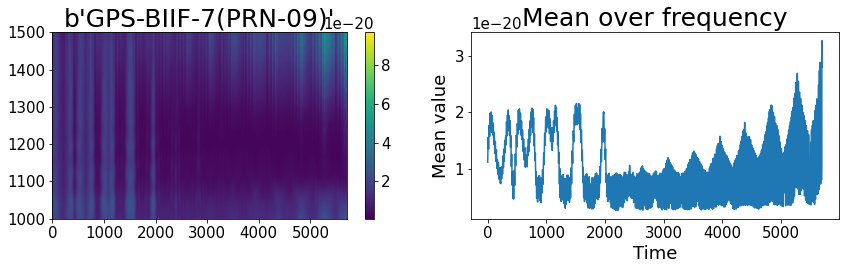

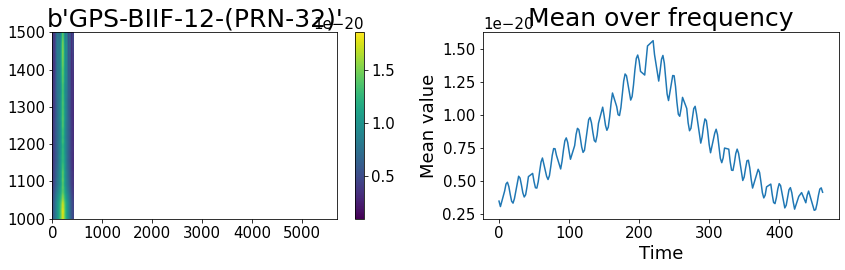

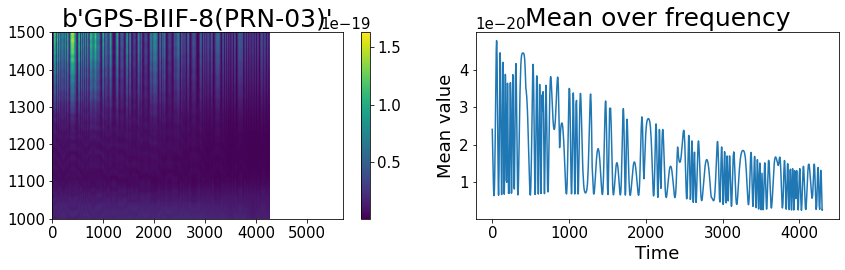

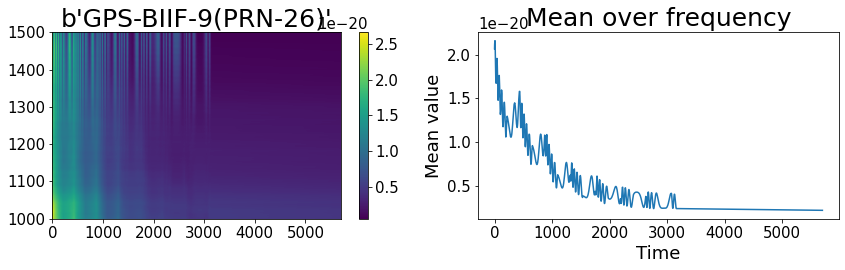

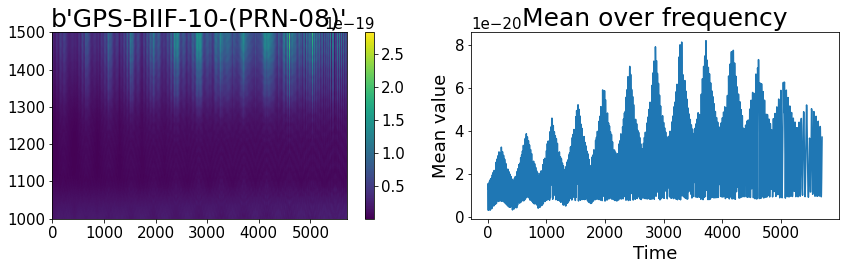

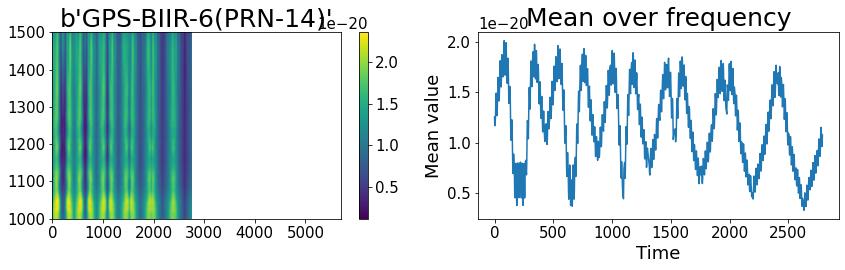

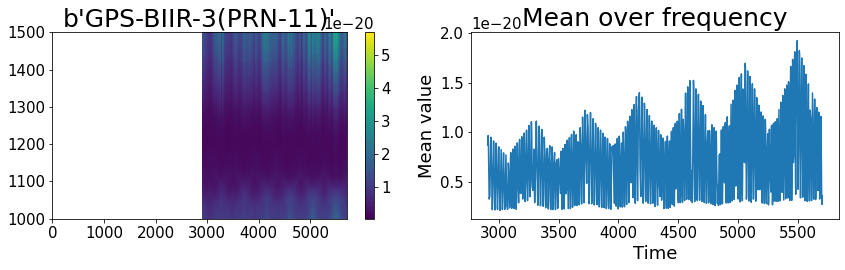

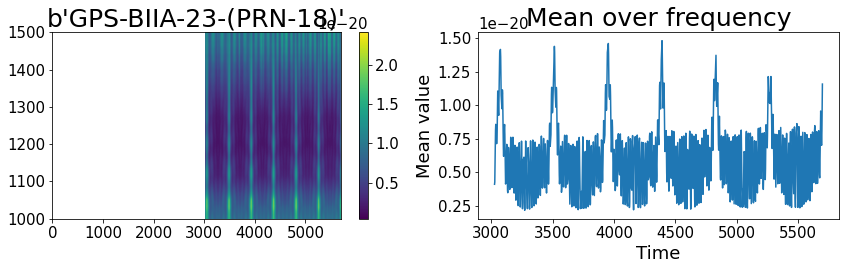

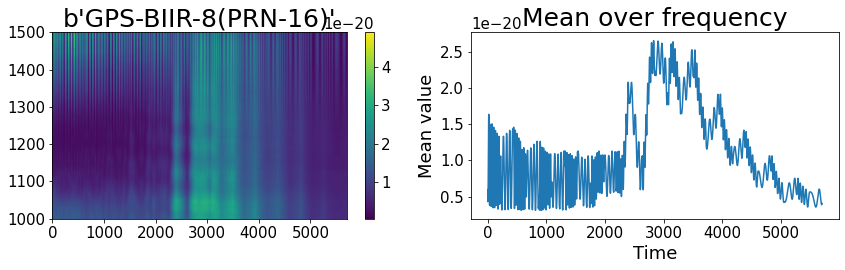

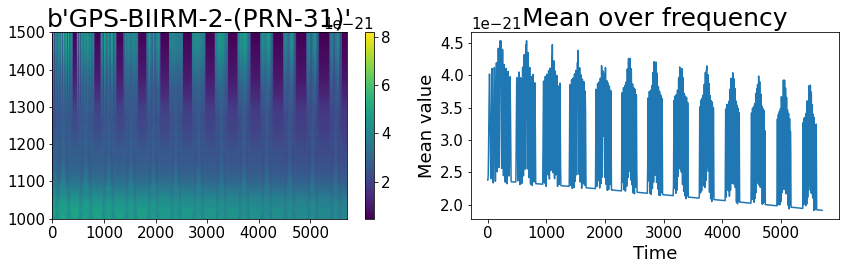

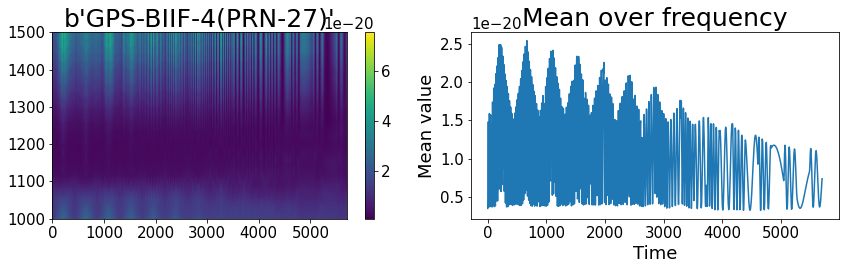

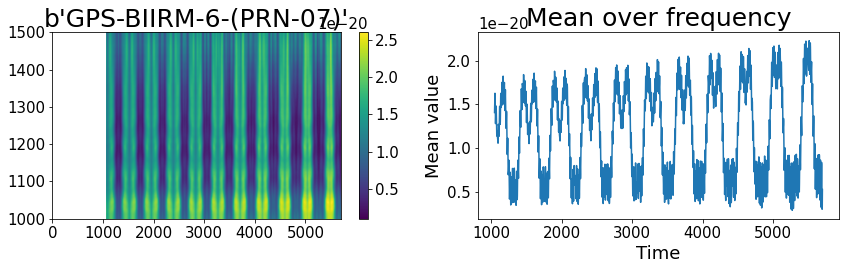

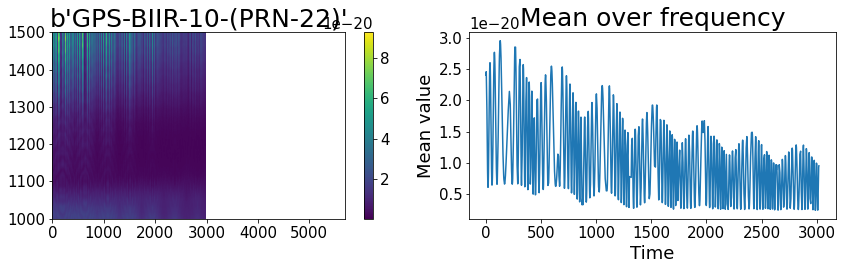

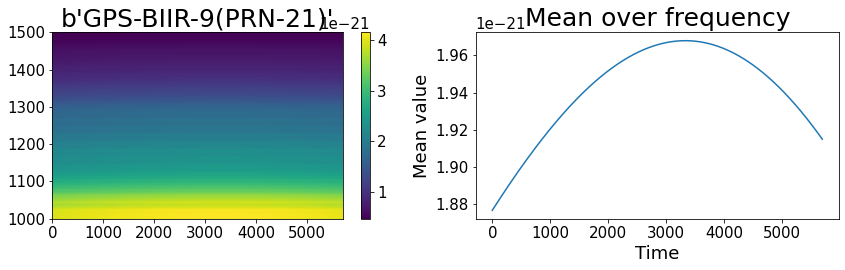

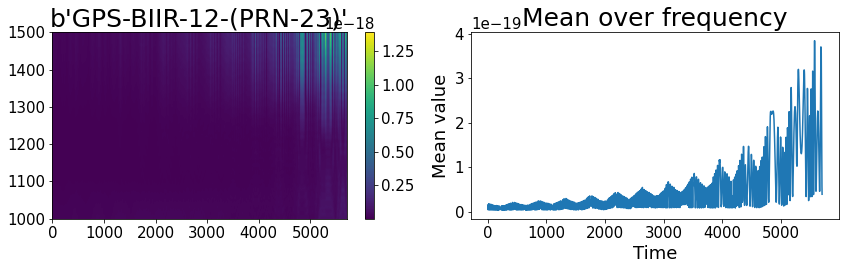


ITEM:  galileo


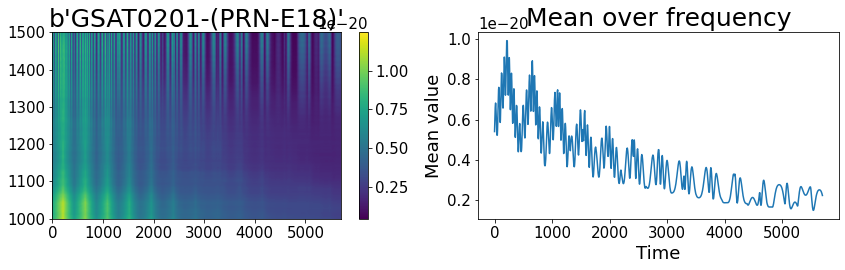

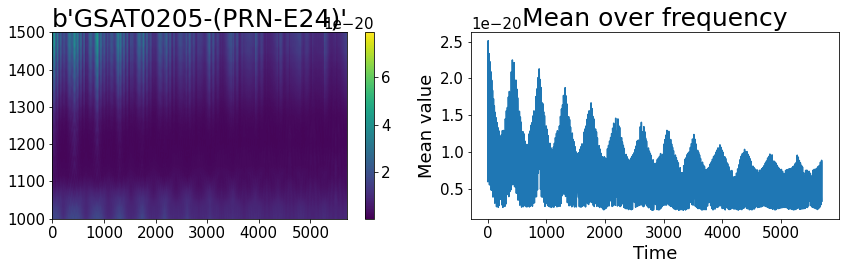

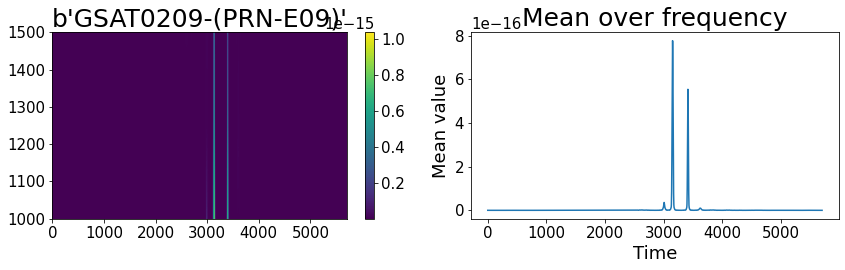

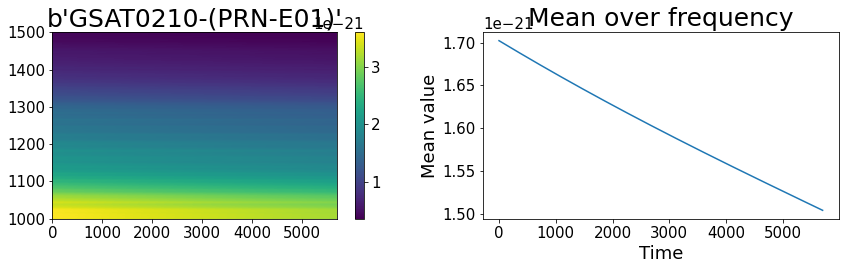

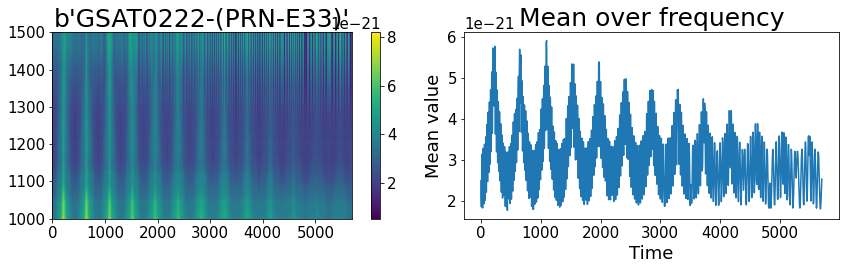

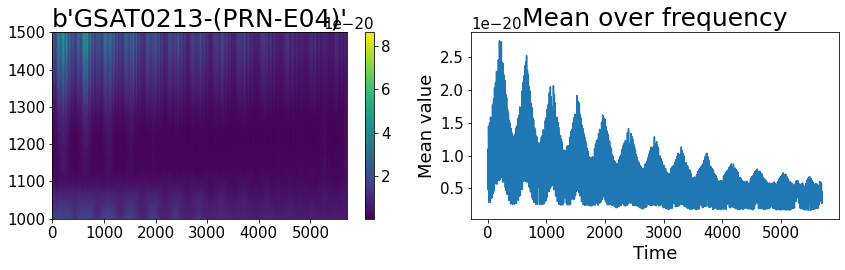

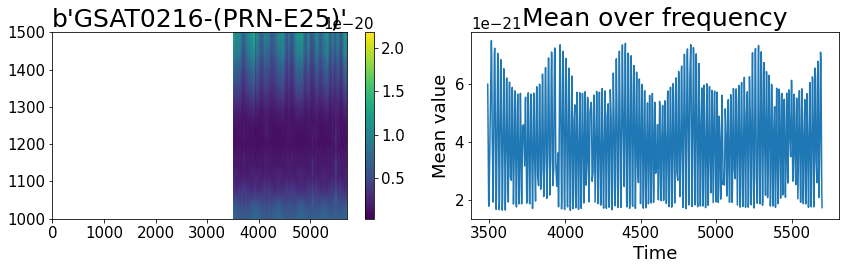

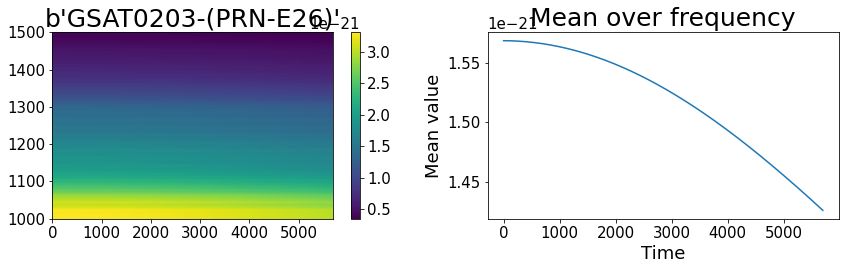

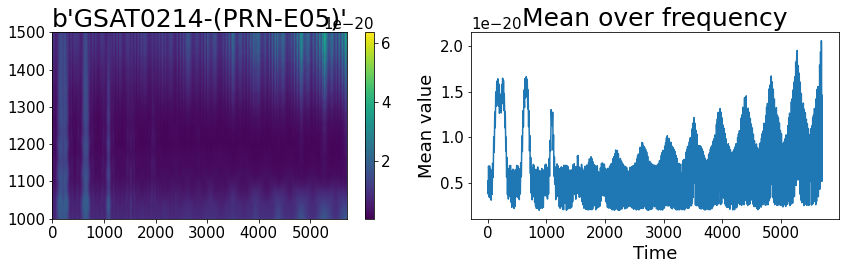

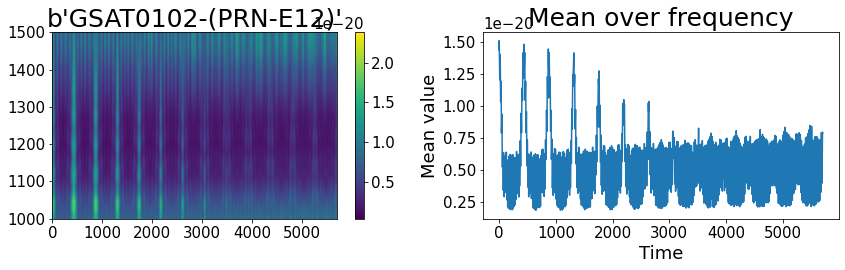

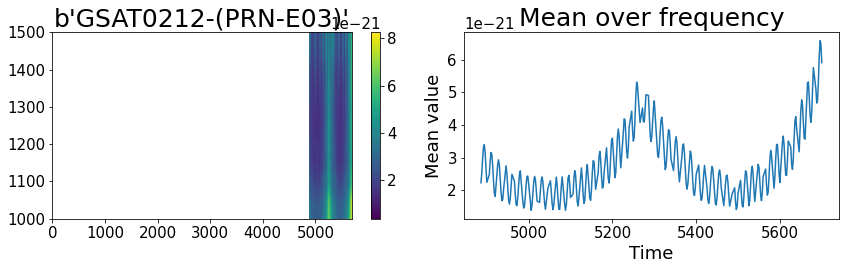

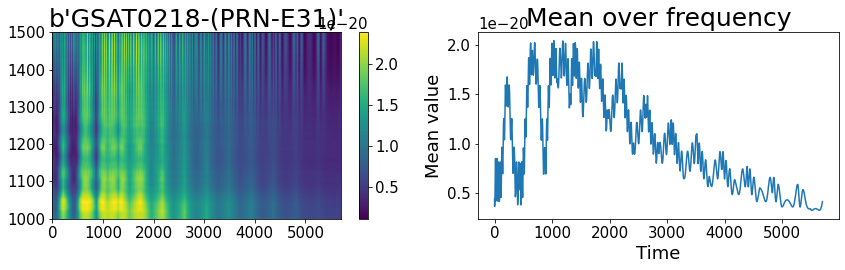

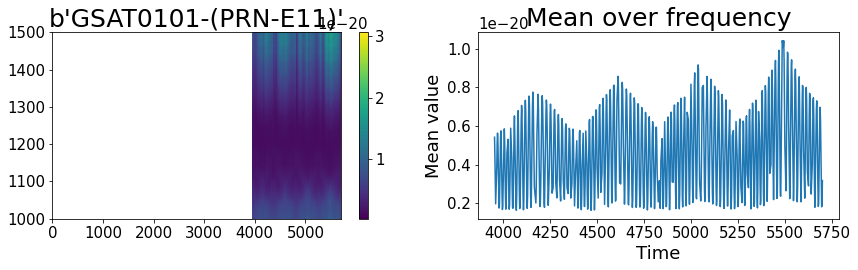


ITEM:  irnss


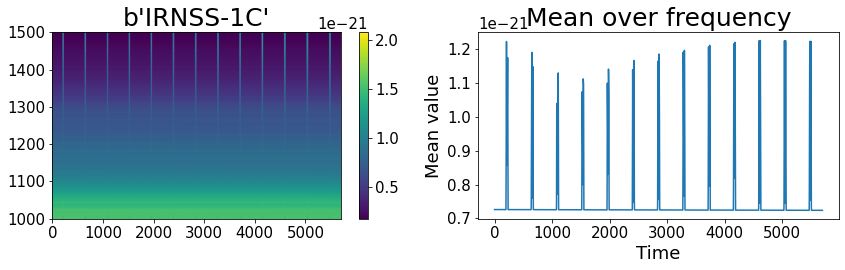

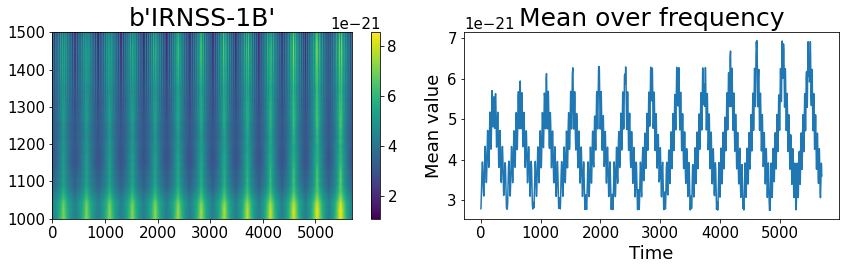

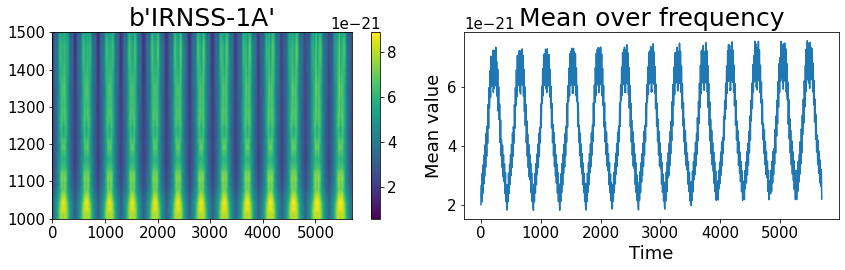

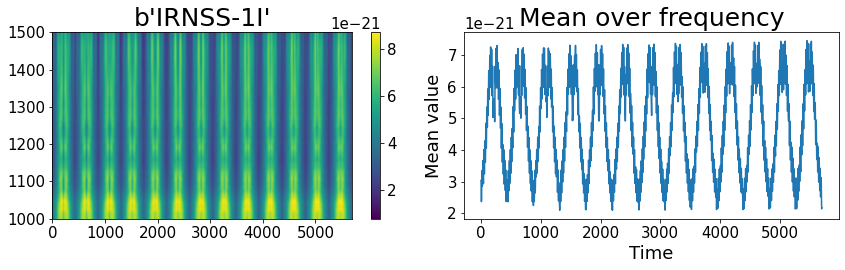

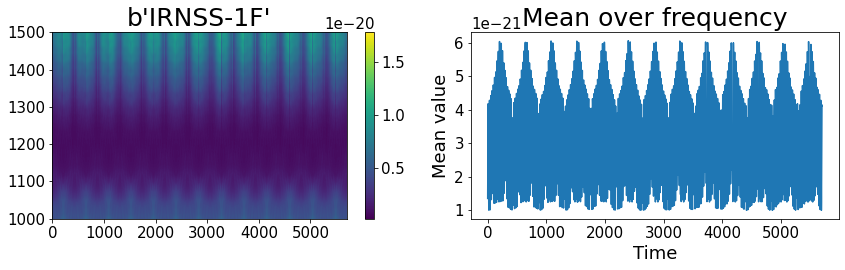


ITEM:  sbas


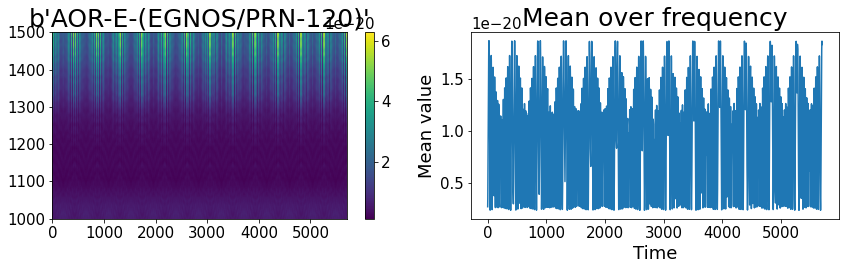

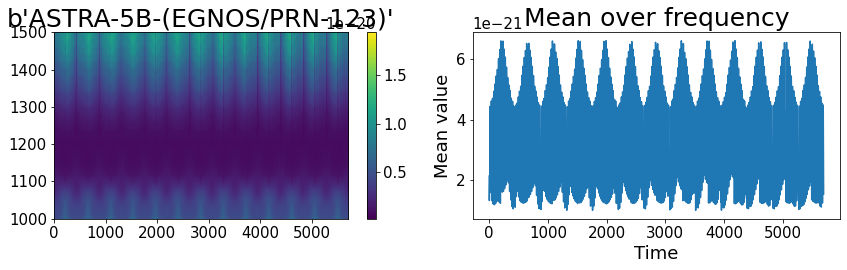

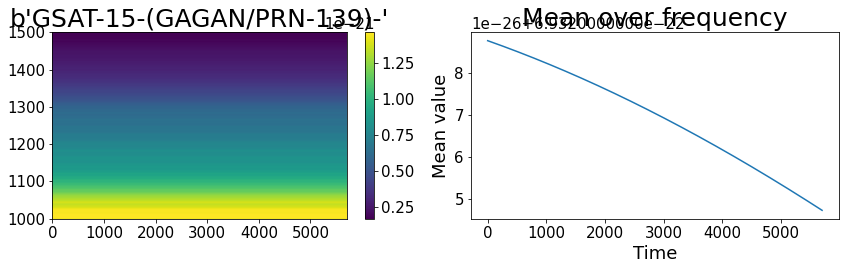

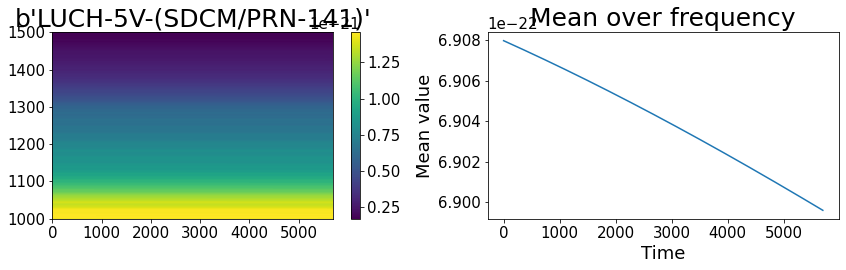

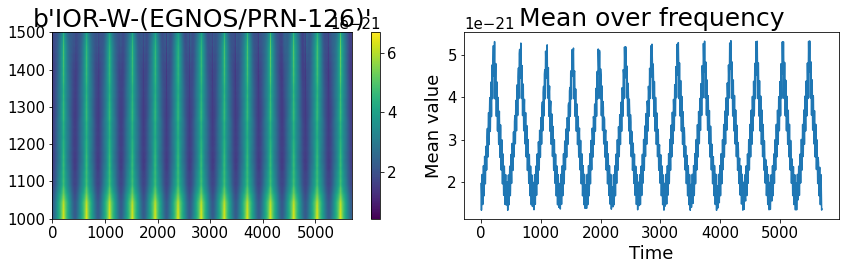

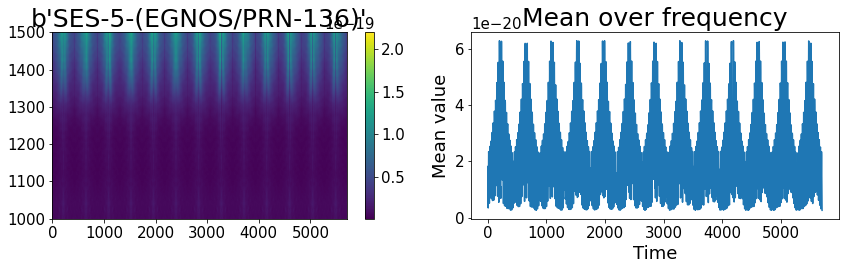

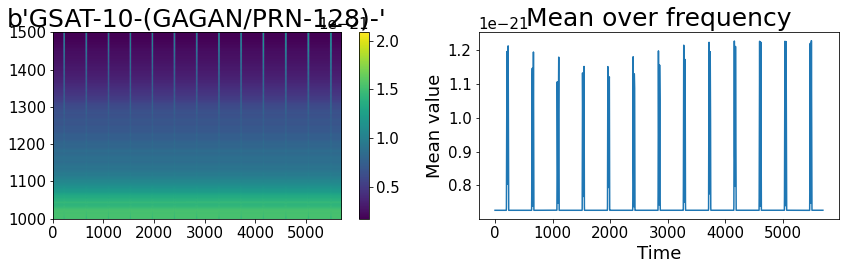

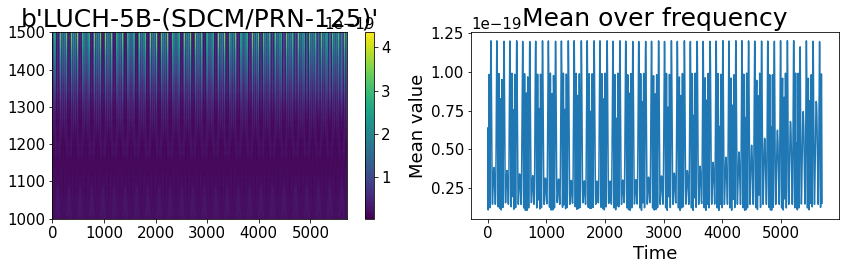

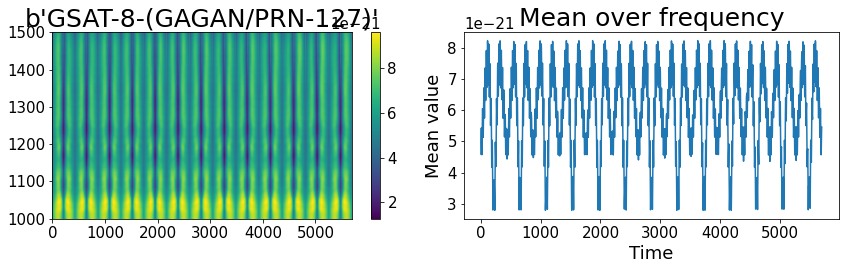


ITEM:  glo-ops


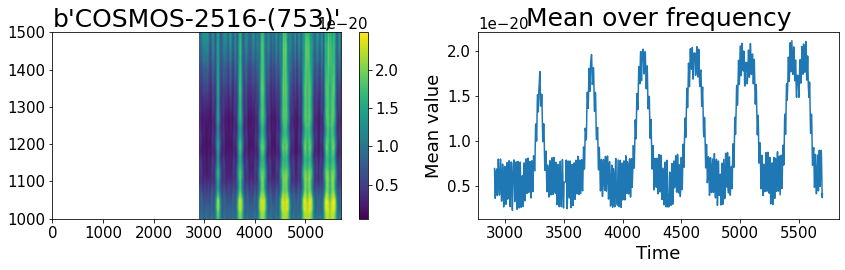

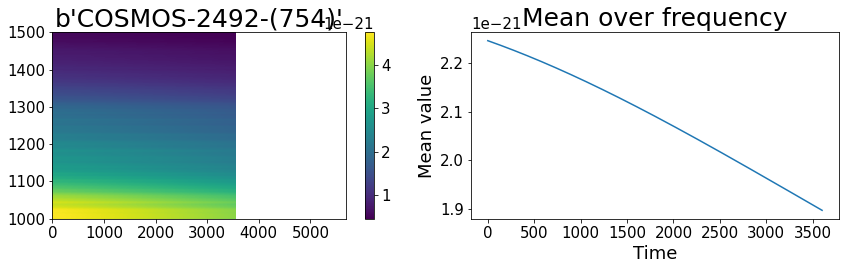

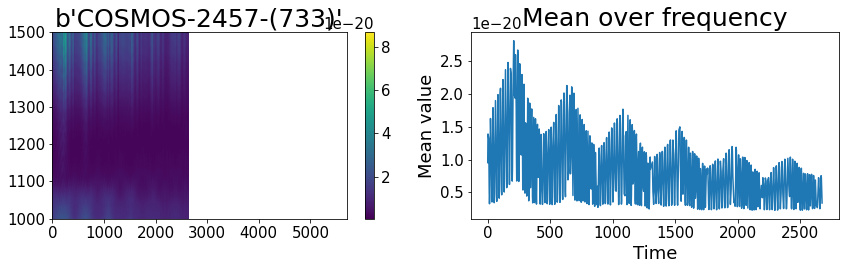

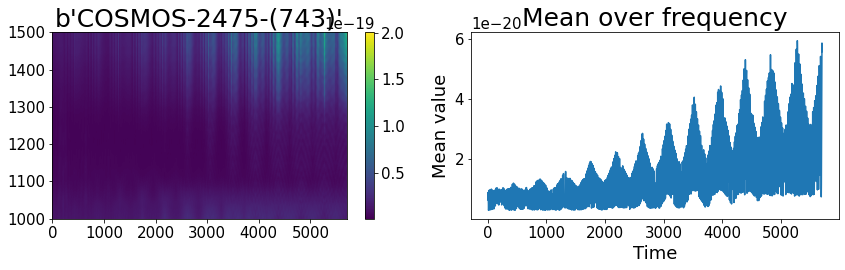

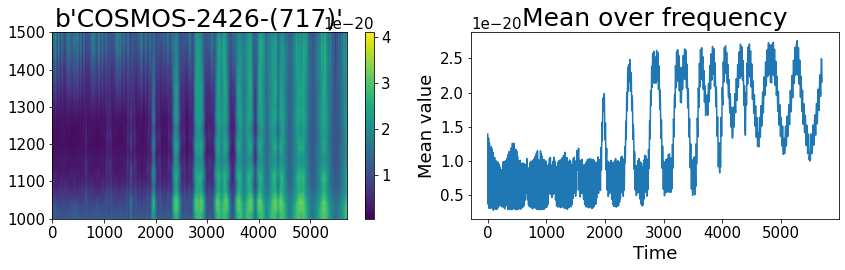

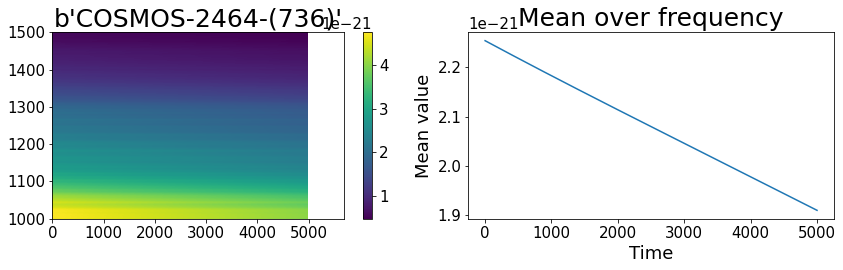

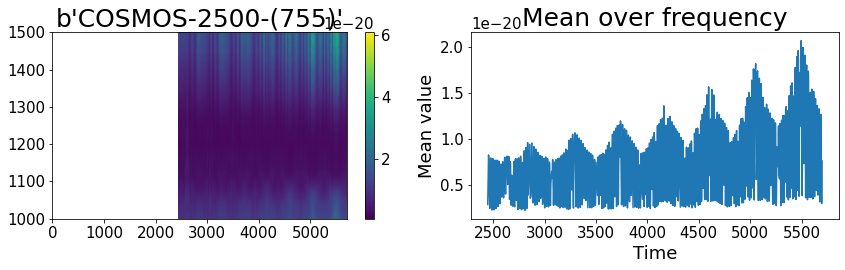

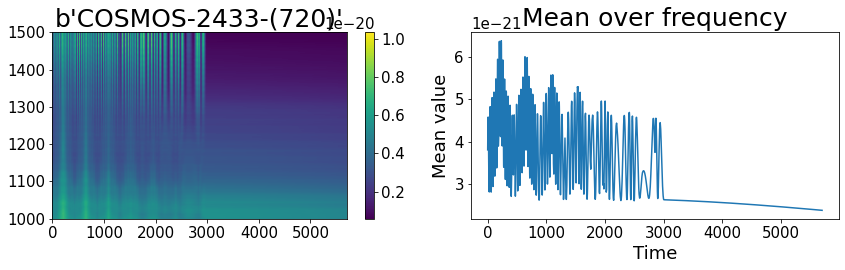

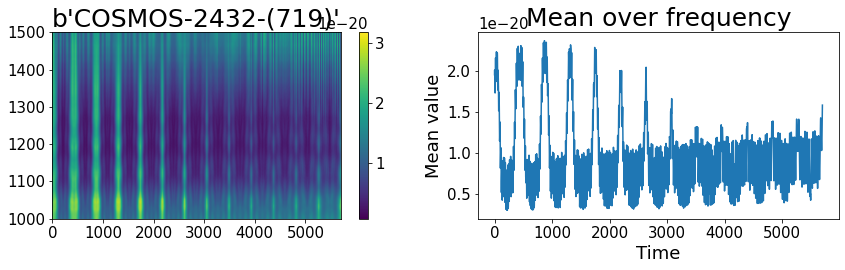

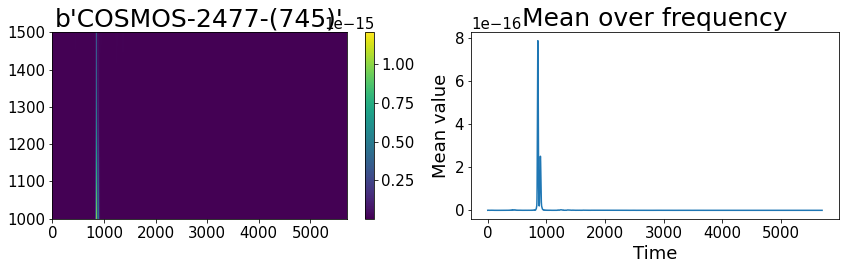

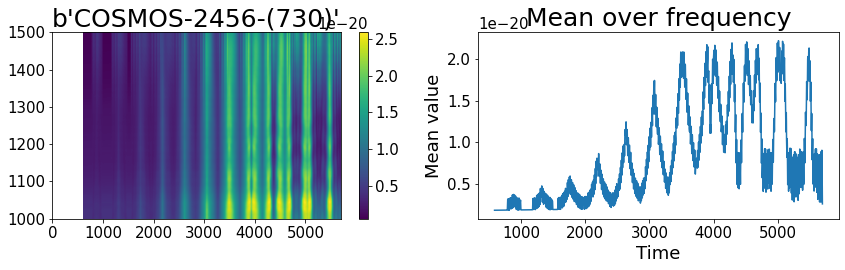

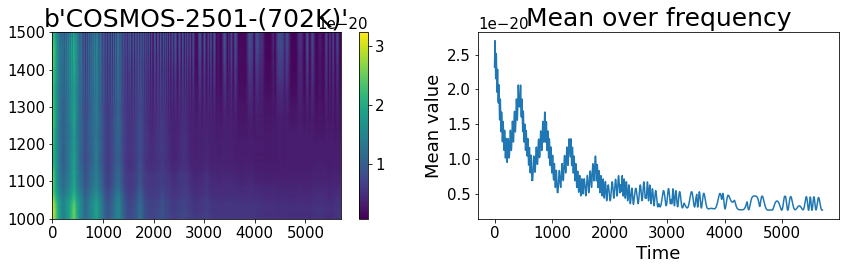

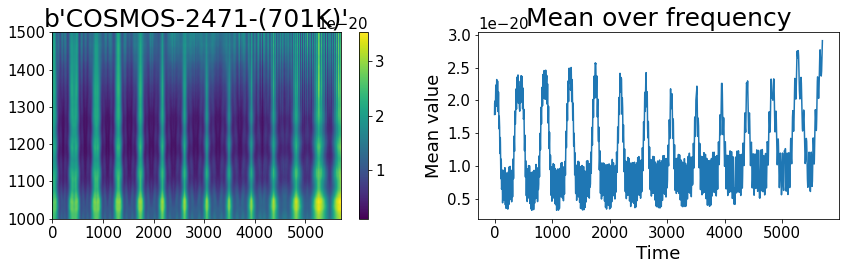


ITEM:  beidou


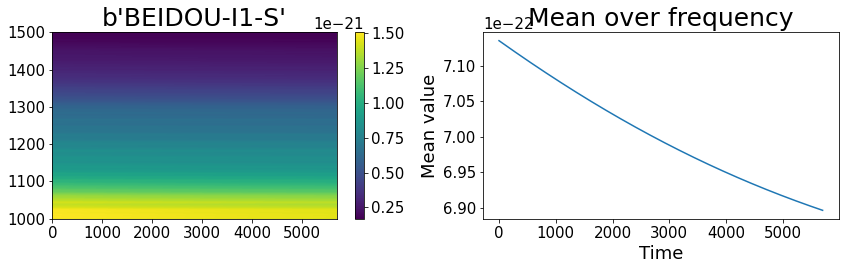

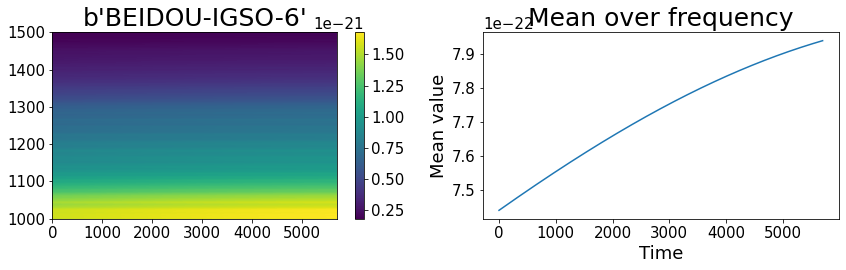

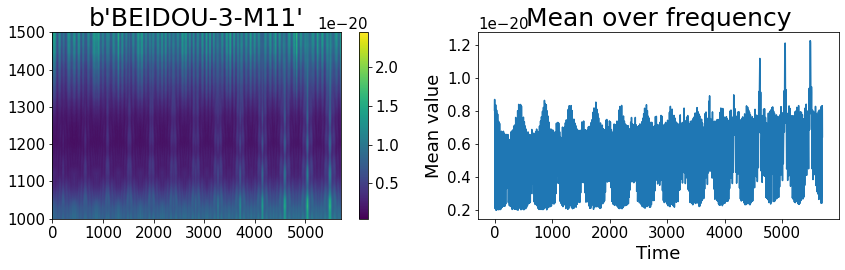

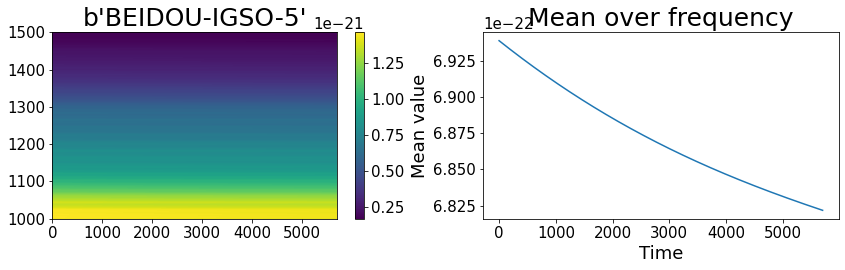

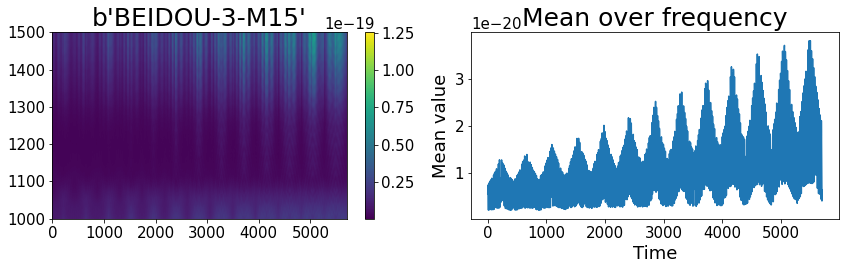

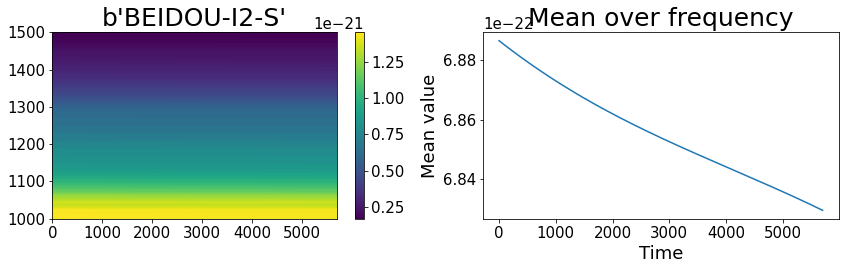

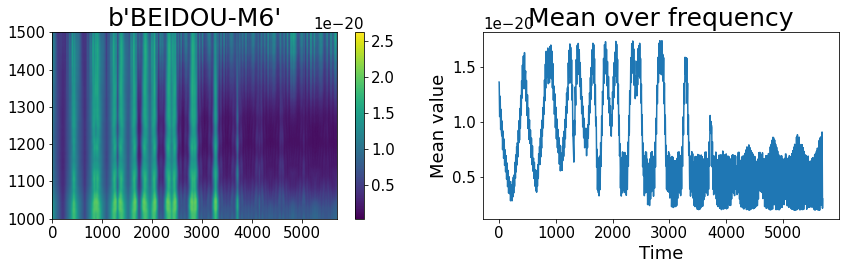

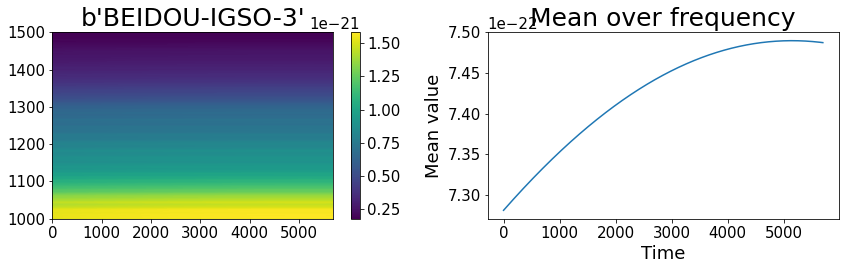

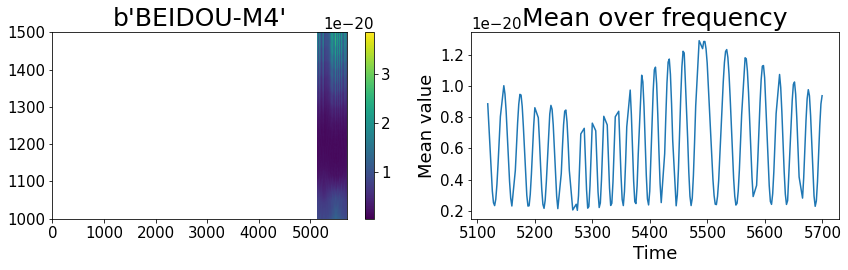

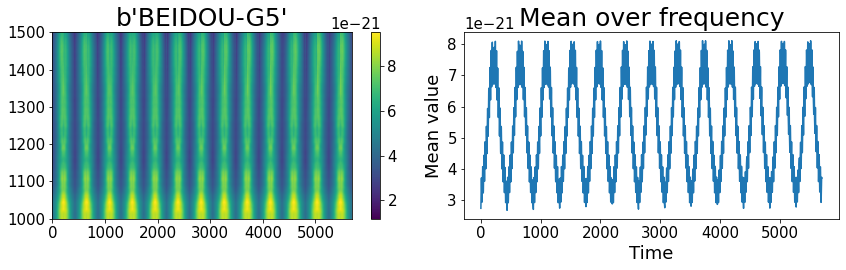

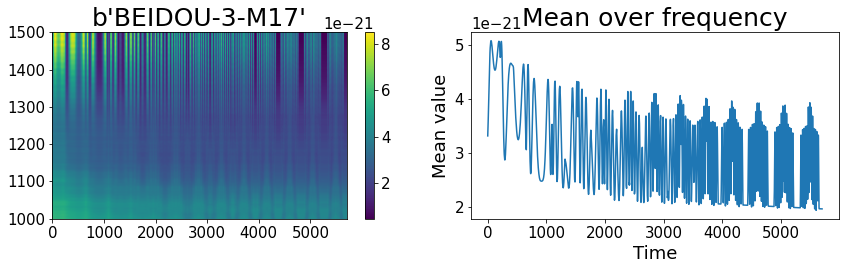

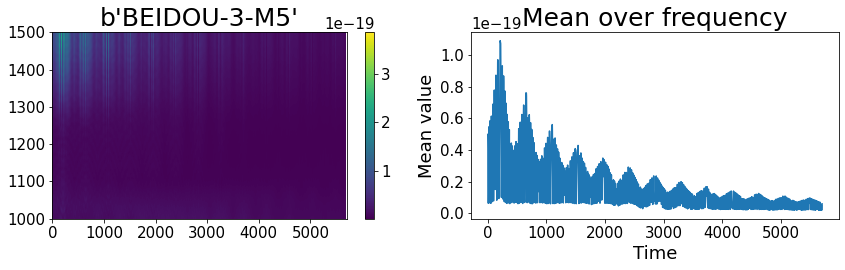

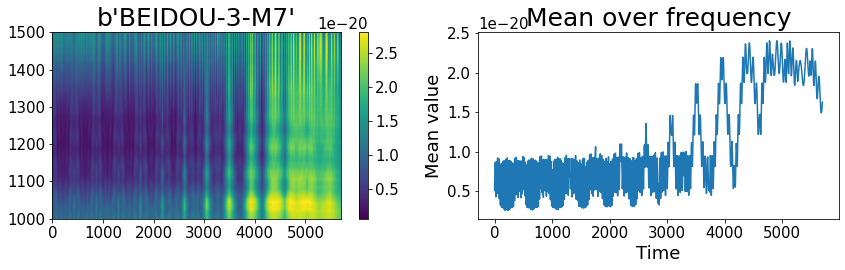

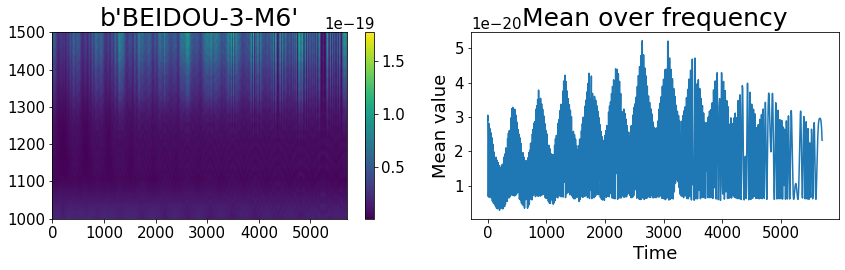

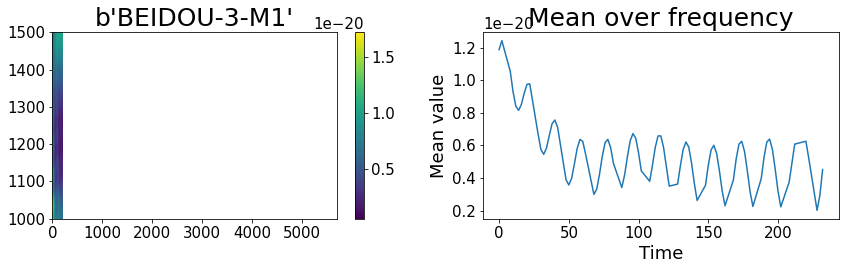

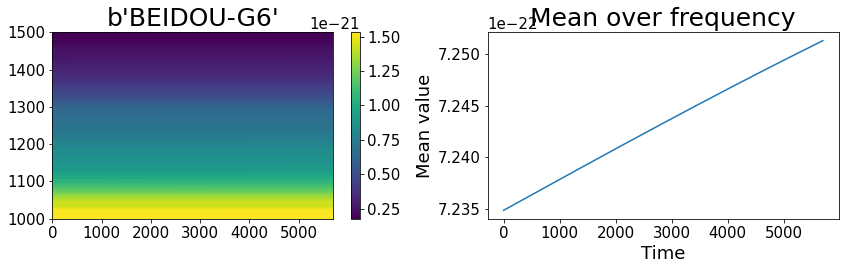

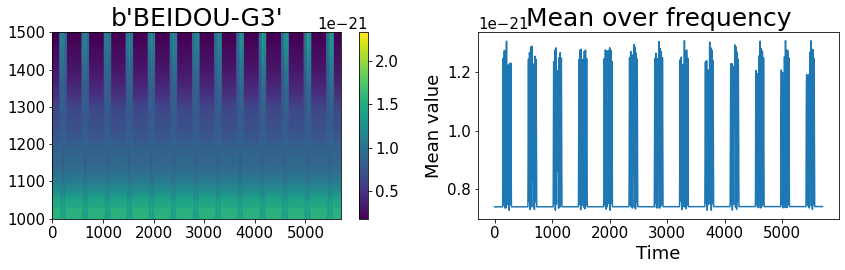

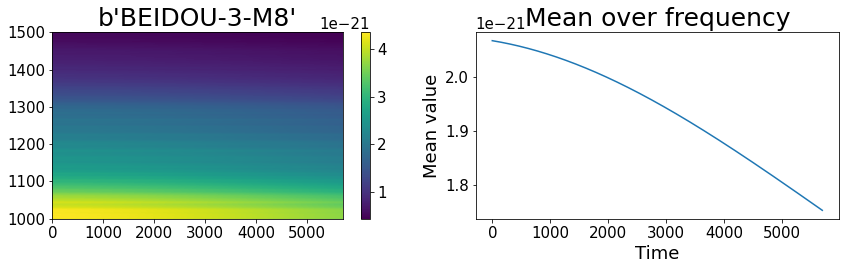

In [6]:
for k in f2.keys():
    #if k=="gps-ops":  continue
    print("ITEM: ",k)
    for i in f2[k].keys():
        # Left: complete map
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        im = ax1.imshow(f2[k][i], extent=[0,ts[-1]-ts[0],fs[0],fs[-1]], 
                        origin="lower",aspect="auto")
        ax1.set_title(i)
        fig.colorbar(im, ax=ax1)
        
        # Right: mean over frequency
        ax2.plot(ts-ts[0], np.mean(f2[k][i], axis=0))
        ax2.set_title("Mean over frequency")
        ax2.set_xlabel("Time")
        ax2.set_ylabel("Mean value")
        plt.tight_layout()
        plt.show()
    print()

#### D. Rewriting data

I'm now re-organizing the data so that it takes less time to load and it's more in-line with my own catalogs. I save the new file as "*{}_satbeams_{}_{}-{}.pkl*" in the */data/* folder. By chance, the satellite that we get is M1 and not M1S, and so we don't need to deal with that fact further because the name is M1 in the old code and the satellite catalog is now updated with the new names.

In [46]:
def reformat(string):
    ''' Removes some "-" '''
    return (string.split("(")[0].rstrip("-") + "(" + string.split("(")[1]).rstrip("-")
    

In [47]:
# getting satellite data
satellites = pd.read_csv(pm.folder + "satellites.csv")

# creating a new index with better formatting
new_index = []
for i in satellites[f"Name {pm.block}"]:
    if pd.isnull(i) or ("BEIDOU" in i) or ("IRNSS" in i):  new_i = i
    else:  new_i = reformat(i)
    new_index.append(new_i)

# setting index
satellites[f"Name {pm.block}"] = new_index
satellites = satellites.set_index(f"Name {pm.block}")


In [48]:
# storing info
data = {}

# parsing through each satellite
print("Saving as dictionary...")
for cons in f2.keys():
    for sat in f2[cons].keys():
        if ("BEIDOU" in sat.decode()) or ("IRNSS" in sat.decode()):  name = sat.decode()
        else:  name = reformat(sat.decode())
        ID = satellites.at[name, "NORAD ID"]
        print(f"Sat {sat.decode()} will become ID {ID}.")
        matrix = f2[cons][sat].filled(0)
        data[ID] = matrix
print("Done")


Saving as dictionary...
Sat GPS-BIIF-7(PRN-09) will become ID 40105.
Sat GPS-BIIF-12-(PRN-32) will become ID 41328.
Sat GPS-BIIF-8(PRN-03) will become ID 40294.
Sat GPS-BIIF-9(PRN-26) will become ID 40534.
Sat GPS-BIIF-10-(PRN-08) will become ID 40730.
Sat GPS-BIIR-6(PRN-14) will become ID 26605.
Sat GPS-BIIR-3(PRN-11) will become ID 25933.
Sat GPS-BIIA-23-(PRN-18) will become ID 22877.
Sat GPS-BIIR-8(PRN-16) will become ID 27663.
Sat GPS-BIIRM-2-(PRN-31) will become ID 29486.
Sat GPS-BIIF-4(PRN-27) will become ID 39166.
Sat GPS-BIIRM-6-(PRN-07) will become ID 32711.
Sat GPS-BIIR-10-(PRN-22) will become ID 28129.
Sat GPS-BIIR-9(PRN-21) will become ID 27704.
Sat GPS-BIIR-12-(PRN-23) will become ID 28361.
Sat GSAT0201-(PRN-E18) will become ID 40128.
Sat GSAT0205-(PRN-E24) will become ID 40889.
Sat GSAT0209-(PRN-E09) will become ID 41174.
Sat GSAT0210-(PRN-E01) will become ID 41550.
Sat GSAT0222-(PRN-E33) will become ID 43565.
Sat GSAT0213-(PRN-E04) will become ID 41861.
Sat GSAT0216-(PRN

In [50]:
# saving information
fname = pm.folder + f"satbeams_{pm.block}_{pm.beam_model}_{pm.freq_range[0]}-{pm.freq_range[1]}.pkl"
with open(fname, "wb") as f:
    pickle.dump(data, f)


In [53]:
# retrieving it much faster
start = time.perf_counter()
f3 = pickle.load(open(fname,"rb",), encoding="latin1")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


This took 3.28 seconds, or 0.05 minutes


## 3. Creating the final signal list (specific to the particular observation)

#### A. Getting data

And now we create a signal catalog of all signals to fit in the data, where we use only the satellites that appear in the angular position maps. 

In [10]:
# getting signal and satellite list
signals = pd.read_csv("data/signals.csv")
satellites = pd.read_csv("data/satellites.csv")

# setting indexes
satellites = satellites.set_index("NORAD ID")


#### B. Creating new updated dataframe based on generation

We now create a signal list same as before, but now taking into account the specific generation that the satellite belongs to.

In [11]:
# creating necessary lists
data2 = []
IDrow = []

print("Selecting signals...")
for ID in data.keys():

    # selecting the generation and constellation
    gen = satellites.at[ID,"Generation"]
    cons = satellites.at[ID,"Constellation"]

    # parsing through the signals
    signals2 = signals[signals["Constellation"]==cons]
    for i in signals2.index:
        if gen in signals2.loc[i,"Generations"].split(","):
            data2.append(signals2.loc[i])
            IDrow.append(ID)
print("Done!")

# creating dataframe
data2 = pd.DataFrame(data2)
data2.insert(0, "NORAD ID", IDrow)


Selecting signals...
Done!


#### C. Dealing with GLONASS k numbers

The k numbers make it so that the central frequencies in L1:L1OF(C/A), L1:L1SF(P), L2:L2OF(C/A) and L2:L2SF(P) are now $f_{L1}=1602.0+0.5625~k\text{ MHz}$ and $f_{L2}=1246.0+0.4375~k\text{ MHz}$.

In [12]:
# getting k numbers
ks = pd.read_csv("data/knumbers_25022019.csv")
ks = ks.set_index("NORAD ID")


In [13]:
# parsing through GLONASS satellites
print("Substituting correct frequencies...")
for ID in data.keys():
    if satellites.at[ID,"Constellation"]=="GLONASS":
        # getting quantities
        k = ks.at[ID,"k"]
        mask1 = data2["NORAD ID"]==ID
        
        # substituting values
        data2.loc[mask1 & (data2["Signal"]=="L1:L1OF(C/A)"), "Frequency(MHz)"] = 1602.0 + k*0.5625
        data2.loc[mask1 & (data2["Signal"]=="L1:L1SF(P)"), "Frequency(MHz)"] = 1602.0 + k*0.5625
        data2.loc[mask1 & (data2["Signal"]=="L2:L2OF(C/A)"), "Frequency(MHz)"] = 1246.0 + k*0.4375
        data2.loc[mask1 & (data2["Signal"]=="L2:L2SF(P)"), "Frequency(MHz)"] = 1246.0 + k*0.4375
print("Done!")


Substituting correct frequencies...
Done!


In [14]:
display(data2[data2["Constellation"]=="GLONASS"])

,NORAD ID,Constellation,Generations,Signal,Frequency(MHz),Rate(MHz),Modulation,P(dBW),G(dBi)
8,41554,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1602.0000,0.5115,BPSK(0.5),10.0,10.0
9,41554,GLONASS,"M,M+,K1,K2",L1:L1SF(P),1602.0000,5.1150,BPSK(5),10.0,10.0
10,41554,GLONASS,"M,M+,K1,K2",L2:L2OF(C/A),1246.0000,0.5115,BPSK(0.5),10.0,10.0
11,41554,GLONASS,"M,M+,K1,K2",L2:L2SF(P),1246.0000,5.1150,BPSK(5),10.0,10.0
12,41554,GLONASS,"M+,K1,K2",L3:L3OC,1202.0250,10.2300,BPSK(10),10.0,10.0
8,39620,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1600.3125,0.5115,BPSK(0.5),10.0,10.0
9,39620,GLONASS,"M,M+,K1,K2",L1:L1SF(P),1600.3125,5.1150,BPSK(5),10.0,10.0
10,39620,GLONASS,"M,M+,K1,K2",L2:L2OF(C/A),1244.6875,0.5115,BPSK(0.5),10.0,10.0
11,39620,GLONASS,"M,M+,K1,K2",L2:L2SF(P),1244.6875,5.1150,BPSK(5),10.0,10.0
8,36112,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1599.7500,0.5115,BPSK(0.5),10.0,10.0


#### D. Rewriting data

Name will depend on the observation because this is tailored specifically to the observation that we are fitting (only satellites in here are the ones appearing in the beam maps); in order to fit other data, this process needs to be repeated (but the signal and satellite files all can be used at will).

Information on constellation and generation is alreeady presented in the satellites file, and they are only useful for later interpretation of the data; likewise, the rate is already encoded in the modulation. As such, these columns are removed from the final signal list.


In [15]:
# dropping unnecessary columns
data2 = data2.drop(columns=["Constellation","Generations","Rate(MHz)"])


In [16]:
# saving the final signal list
fname = folder + f"catalog_{pm.block}.csv"
data2.to_csv(fname, index=False)
